<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/backtest_enet_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

CRSP_PATH = "/content/drive/MyDrive/backtest/crsp_monthly.parquet"
PRED_PATH = "/content/drive/MyDrive/backtest/enet_huber_results.parquet"
YEAR_INFO_PATH = "/content/drive/MyDrive/backtest/enet_huber_year_info.csv"
OUTPUT_DIR = "/content/drive/MyDrive/backtest/Outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("CRSP_PATH =", CRSP_PATH)
print("PRED_PATH =", PRED_PATH)
print("YEAR_INFO_PATH =", YEAR_INFO_PATH)
print("OUTPUT_DIR =", OUTPUT_DIR)

CRSP_PATH = /content/drive/MyDrive/backtest/crsp_monthly.parquet
PRED_PATH = /content/drive/MyDrive/backtest/enet_huber_results.parquet
YEAR_INFO_PATH = /content/drive/MyDrive/backtest/enet_huber_year_info.csv
OUTPUT_DIR = /content/drive/MyDrive/backtest/Outputs


In [ ]:
def assign_decile(x):
    if len(x) < 10:
        return pd.Series(index=x.index, data=np.nan)
    ranks = x.rank(method='first', ascending=True)
    return pd.qcut(ranks, 10, labels=False) + 1

In [ ]:
def cumulate_return(df, date_col, rank_col, ret_col, weighting="equal"):
    df = df.copy()
    df["decile"] = df.groupby(date_col)[rank_col].transform(assign_decile)

    if weighting == "equal":
        raw_port_ret = df.groupby([date_col, "decile"])[ret_col].mean()

    elif weighting == "value":
        df = df.sort_values(["permno", date_col])
        df["me_lag"] = df.groupby("permno")["me"].shift(1)
        df = df.dropna(subset=["me_lag"])

        raw_port_ret = (
            df.groupby([date_col, "decile"])
            .apply(lambda x: np.sum(x[ret_col] * x["me_lag"]) / np.sum(x["me_lag"]), include_groups=False)
        )
    else:
        raise ValueError("weighting must be 'equal' or 'value'")

    port_ret = raw_port_ret.unstack("decile")
    port_ret["LS"] = port_ret[10] - port_ret[1]
    port_ret["LS_ariret"] = port_ret["LS"].cumsum()

    return port_ret.reset_index()

In [ ]:
def ret_plot(port_ret, model_name, weighting):
    plt.figure(figsize=(10, 5))
    plt.plot(port_ret["date"], port_ret["LS_ariret"])
    plt.title(f"{weighting.capitalize()}-Weighted Long-Short based on {model_name}")
    plt.xlabel("Date")
    plt.ylabel("Arithmetic Return")
    plt.grid(True)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    save_path = os.path.join(OUTPUT_DIR, f"{model_name}_{weighting}_ret.png")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Return plot saved to: {save_path}")

In [ ]:
def ret_summary(port_ret):
    ls_ret = port_ret["LS"].dropna()
    mean_monthly = ls_ret.mean()
    std_monthly = ls_ret.std()
    sharpe = (mean_monthly / std_monthly) * np.sqrt(12)
    return sharpe

def oos_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)

In [ ]:
def load_and_merge_data(crsp_path=CRSP_PATH, pred_path=PRED_PATH):
    crsp = pd.read_parquet(crsp_path)
    pred = pd.read_parquet(pred_path)

    if "date" not in crsp.columns:
        raise KeyError("crsp_monthly.parquet 里必须有 date 列")
    if "permno" not in crsp.columns:
        raise KeyError("crsp_monthly.parquet 里必须有 permno 列")
    if "ret" not in crsp.columns:
        raise KeyError("crsp_monthly.parquet 里必须有 ret 列")
    if "me" not in crsp.columns:
        raise KeyError("crsp_monthly.parquet 里必须有 me 列，value-weight 会用到")
    if "DATE" not in pred.columns:
        raise KeyError("enet_huber_results.parquet 里必须有 DATE 列")
    if "permno" not in pred.columns:
        raise KeyError("enet_huber_results.parquet 里必须有 permno 列")
    if "y_true" not in pred.columns or "y_pred" not in pred.columns:
        raise KeyError("enet_huber_results.parquet 里必须有 y_true 和 y_pred 列")

    crsp["date"] = pd.to_datetime(crsp["date"])
    pred["DATE"] = pd.to_datetime(pred["DATE"])

    crsp["date_m"] = crsp["date"].dt.to_period("M")
    pred["date_m"] = pred["DATE"].dt.to_period("M")

    panel = crsp.merge(pred, on=["permno", "date_m"], how="inner", suffixes=("", "_pred"))
    return crsp, pred, panel

In [ ]:
crsp, pred, panel = load_and_merge_data()

print("crsp shape:", crsp.shape)
print("pred shape:", pred.shape)
print("merged panel shape:", panel.shape)

display(panel.head())

crsp shape: (1917129, 5)
pred shape: (2476033, 6)
merged panel shape: (1902025, 9)


,permno,date,ret,me,date_m,DATE,y_true,y_pred,mvel1
0,10000,1987-01-30,-0.212121,1581.53125,1987-01,1987-01-30,-0.004300,0.002715,-0.921324
1,10001,1987-01-30,-0.035714,6689.25,1987-01,1987-01-30,-0.078374,0.005474,-0.671628
2,10002,1987-01-30,0.09596,15935.9375,1987-01,1987-01-30,-0.018125,0.002891,-0.413730
3,10003,1987-01-30,0.12987,47523.75,1987-01,1987-01-30,0.007194,-0.002427,0.030073
4,10005,1987-01-30,0.666667,722.8125,1987-01,1987-01-30,0.095700,-0.003038,-0.994228


In [ ]:
def run_trade_pipeline(pred_path=PRED_PATH, weighting="equal"):
    _, _, panel = load_and_merge_data(pred_path=pred_path)

    model_name = os.path.splitext(os.path.basename(pred_path))[0]

    port_ret = cumulate_return(
        df=panel,
        date_col="date",
        rank_col="y_pred",
        ret_col="ret",
        weighting=weighting
    )

    port_exret = cumulate_return(
        df=panel,
        date_col="date",
        rank_col="y_pred",
        ret_col="y_true",
        weighting=weighting
    )

    ret_plot(port_ret, model_name, weighting)

    information_ratio = ret_summary(port_ret)
    sharpe_ratio = ret_summary(port_exret)
    r2 = oos_r2(panel["y_true"], panel["y_pred"])

    summary_text = (
        f"Model: {model_name}\n"
        f"Weighting: {weighting}\n"
        f"Annualized Sharpe Ratio: {sharpe_ratio:.4f}\n"
        f"Information Ratio: {information_ratio:.4f}\n"
        f"Predictive R-squared: {r2:.6f}\n"
    )

    summary_path = os.path.join(OUTPUT_DIR, f"{model_name}_{weighting}_summary.txt")
    port_path = os.path.join(OUTPUT_DIR, f"{model_name}_{weighting}_portfolio_returns.csv")

    with open(summary_path, "w") as f:
        f.write(summary_text)

    port_ret.to_csv(port_path, index=False)

    print(summary_text)
    print("Summary saved to:", summary_path)
    print("Portfolio returns saved to:", port_path)

    return port_ret

## Run equal-weight

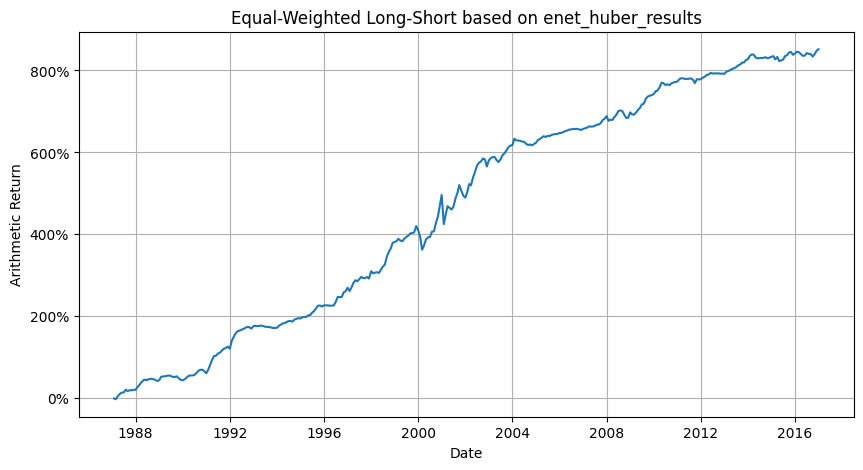

Return plot saved to: /content/drive/MyDrive/backtest/Outputs/enet_huber_results_equal_ret.png
Model: enet_huber_results
Weighting: equal
Annualized Sharpe Ratio: 0.8740
Information Ratio: 1.1134
Predictive R-squared: 0.003078

Summary saved to: /content/drive/MyDrive/backtest/Outputs/enet_huber_results_equal_summary.txt
Portfolio returns saved to: /content/drive/MyDrive/backtest/Outputs/enet_huber_results_equal_portfolio_returns.csv


In [ ]:
port_ret_equal = run_trade_pipeline(pred_path=PRED_PATH, weighting="equal")

## Run value-weight

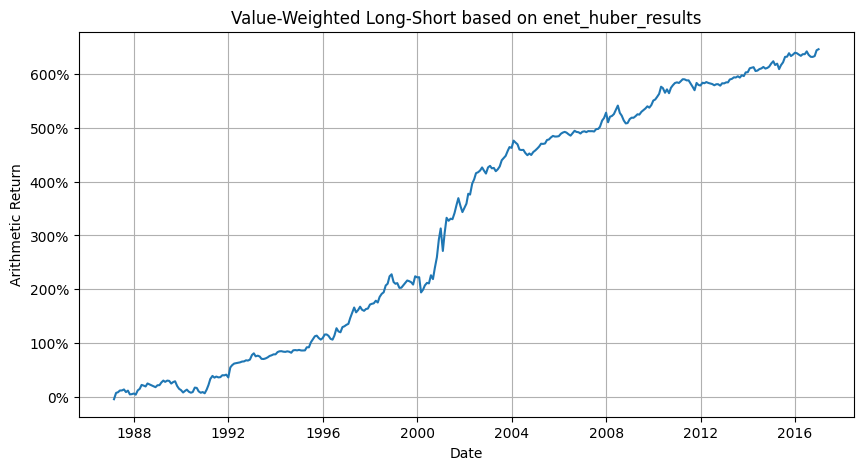

Return plot saved to: /content/drive/MyDrive/backtest/Outputs/enet_huber_results_value_ret.png
Model: enet_huber_results
Weighting: value
Annualized Sharpe Ratio: 0.7844
Information Ratio: 0.9113
Predictive R-squared: 0.003078

Summary saved to: /content/drive/MyDrive/backtest/Outputs/enet_huber_results_value_summary.txt
Portfolio returns saved to: /content/drive/MyDrive/backtest/Outputs/enet_huber_results_value_portfolio_returns.csv


In [ ]:
port_ret_value = run_trade_pipeline(pred_path=PRED_PATH, weighting="value")

## Optional: inspect yearly diagnostics

In [ ]:
year_info = pd.read_csv(YEAR_INFO_PATH)
print("year_info shape:", year_info.shape)
display(year_info.head())

year_info shape: (30, 15)


,year,n_train,n_val,n_test,lam,xi,nnz,sec,warm_source,gs_avg_iters,gs_converged,refit_iters,refit_converged,refit_restarts,best_val_loss
0,1987,472278,764497,82404,0.003793,1.898741,46,14.289714,zeros,5.153846,13,27,True,2,0.024452
1,1988,530435,788744,83415,0.003793,1.324456,54,13.600049,cross-year,3.923077,13,25,True,2,0.024981
2,1989,588534,814060,81216,0.002637,1.251242,62,15.523492,cross-year,4.538462,13,50,True,2,0.025308
3,1990,647363,836447,80207,0.002637,1.263686,64,16.742617,cross-year,5.076923,13,49,True,2,0.026065
4,1991,704916,859101,79274,0.003793,1.319766,57,16.454053,cross-year,3.846154,13,36,True,2,0.027382
